# EE4410 - Cyber Security of Power Grids 🔐 ⚡
## Lab 5 🔬: Anomaly Detection and Time Series Classification


## Information

## Student Details
### Name: Zubair Al-Zubi
### ID/number: 5342007

Lab 5 provides the following datasets:

1. Wireshark traffic saved in `.csv` format from a digital substation (`pcap_X.csv`, `pcap_Y.csv`, and `pcap_Z.csv`). The X, Y, Z represent different scenarios.
2. Labelled and preprocessed training datasets (`tsc_training_data.csv`) from a digital substation from 11 nodes (A-K) and 11 labels ($A_L - A_K$).
2. Unlabelled and preprocessed traffic  from a digital substation from 11 nodes (A-K). The unlabelled time-series data represents different scenarios (`tsc_X.csv`, `tsc_Y.csv`, and `tsc_Z.csv`)

The notebook provides example code on how to perform the following:
- traffic analysis and
- time series classification

You are expected to run the code for different scenarios and different nodes.
Based on the provided code, conduct data analysis and try to answer the following questions:





In [ ]:
# Load the pre-trained model
model = load_model('dataset/tsc_model.h5')
# Make predictions
predictions = model.predict(X_test)

4/4 [==============================] - 0s 4ms/step


In [1]:
# Imports
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

ModuleNotFoundError: No module named 'keras'

## Part 1: Traffic Analysis

In [ ]:
# Load Dataset

traffic_data_loc = 'dataset/pcap_X.csv'
traffic_data = pd.read_csv(traffic_data_loc)

# Select rows where 'Protocol' is 'TCP'
tcp_ = traffic_data[traffic_data['Protocol'].str.contains('TCP')]

# Create 'Connection' column
tcp_['Connection'] = tcp_[['Source', 'Destination']].apply(lambda x: '-'.join(sorted(x)), axis=1)

# Group by 'Connection' and create separate tables
grouped = tcp_.groupby('Connection')[['Time', 'Connection', 'Length']]

# Dictionary to store DataFrames for each group
dfs = {}

# Split the DataFrame into separate DataFrames and store them in the dictionary
for connection, group_df in grouped:
    dfs[connection] = group_df

# Resample time series data for each group
for connection, group_df in grouped:
    sel_df = dfs[connection]

    # Select two column only Time and Length
    sel_df = sel_df[['Time', 'Length']]

    # Set time unit to Second (S)
    sel_df['Time'] = pd.to_datetime(sel_df['Time'], unit='s')

    # Set 'Time' column as the index
    sel_df.set_index('Time', inplace=True)

    # Resample the DataFrame into 1 second intervals and sum the 'Length' values
    sel_df = sel_df.resample('1S').sum()

    # Fill NaN values with 0 (in case there are no data points in some intervals)
    sel_df['Length'] = sel_df['Length'].fillna(0)

    # Reset index to turn the datetime index into a column
    sel_df.reset_index(inplace=True)

    # Calculate time difference from the first row in Second
    sel_df['Time'] = (sel_df['Time'] - sel_df['Time'].iloc[0]).dt.total_seconds()

    # Update the dfs
    dfs[connection] = sel_df

# Set 'Time' column as index for all DataFrames
for df_name, df in dfs.items():
    # Rename columns
    df = df.rename(columns={'Length': df_name})
    dfs[df_name] = df.set_index('Time')

# Merge DataFrames horizontally based on the index
merged_df = pd.concat(dfs.values(), axis=1)

# Fill NaN values with zero
merged_df = merged_df.fillna(0)

# Create a new column based on index
merged_df['Time'] = merged_df.index
merged_df.reset_index(drop=True, inplace=True)

# Move the new column to the first position
cols = merged_df.columns.tolist()
cols = cols[-1:] + cols[:-1]
merged_df = merged_df[cols]

Show Merged Dataframe

In [ ]:
merged_df.head()

,Time,100.0.0.11-100.7.0.11,100.0.0.11-100.7.0.12,100.0.0.11-100.7.0.13,100.0.0.11-100.7.0.14,100.0.0.11-100.7.0.15,100.0.0.11-100.7.0.16,100.0.0.11-100.7.0.17,100.0.0.11-100.7.0.18,100.0.0.11-100.7.0.19,100.0.0.11-100.7.0.20
0,0.0,176,198.0,198.0,192,162,182,172,190.0,162,190.0
1,1.0,176,198.0,198.0,0,162,182,172,190.0,162,190.0
2,2.0,176,198.0,0.0,192,162,182,172,190.0,162,190.0
3,3.0,176,198.0,198.0,192,162,182,172,190.0,162,0.0
4,4.0,176,0.0,198.0,192,162,182,172,190.0,162,190.0


Plot time-series of traffic in IP source and destidantion: `100.0.0.11-100.7.0.12`

In [ ]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Time']
  ys = series['100.0.0.11-100.7.0.12']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

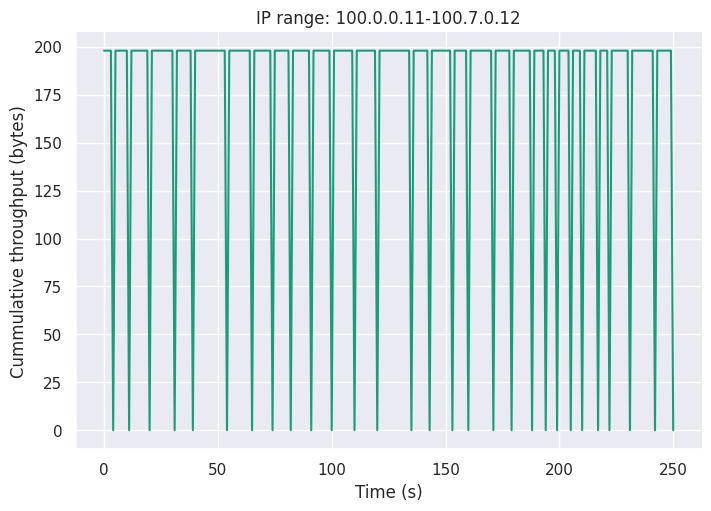

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')
df_sorted = merged_df.sort_values('Time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Time (s)')
plt.title('IP range: 100.0.0.11-100.7.0.12')
_ = plt.ylabel('Cummulative throughput (bytes)')

## Part 2: Time Series Classification

In [ ]:
def create_train_sequences(data, labels, sequence_length):
    X_sequences = []
    y_sequences = []

    for i in range(len(data) - sequence_length + 1):
        X_sequences.append(data[i:i + sequence_length])
        y_sequences.append(labels[i + sequence_length - 1])

    # Replace NaN values with 0
    y = np.array(y_sequences)
    print(np.sum(np.isnan(y)))
    y = np.nan_to_num(y, nan=0)

    return np.array(X_sequences), y


def prepare_train_dataset_univariate(csv_data, sel_data, sel_label, n_classes, sequence_length):
    # _data   = csv_data[[sel_data]].values.reshape(-1, 1)
    # _label  = csv_data[[sel_label]].values

    X, y = create_train_sequences(csv_data[sel_data], csv_data[sel_label], sequence_length)

    # Define the input shape based on sequence length
    input_shape = (X.shape[1], 1)  # Shape: (sequence_length, 1)

    # Reshape X to fit the input shape of the model
    X = X.reshape(-1, *input_shape)

    # Set the label to categorical classes
    y = to_categorical(y, num_classes=n_classes)

    return X, y

def create_test_sequences(data,  sequence_length):
    X_sequences = []

    for i in range(len(data) - sequence_length + 1):
        X_sequences.append(data[i:i + sequence_length])

    return np.array(X_sequences)

def prepare_test_dataset_univariate(csv_data, sel_data, sequence_length):

    X = create_test_sequences(csv_data[sel_data], sequence_length)

    # Define the input shape based on sequence length
    input_shape = (X.shape[1], 1)  # Shape: (sequence_length, 1)

    # Reshape X to fit the input shape of the model
    X = X.reshape(-1, *input_shape)

    return X

Load the dataset

In [ ]:
# location of training test dataset
train_loc = 'dataset/tsc_training_data.csv'
test_loc = 'dataset/test_Y.csv'

#load the training and test dataset
train_data = pd.read_csv(train_loc)
test_data = pd.read_csv(test_loc)

Preprocess the dataset

In [ ]:
### Time Series Univariate Classification
selected_data = 'A'
selected_label = 'A_L'
n_classes = 2
sequence_length = 4

X, y =  prepare_train_dataset_univariate(train_data, selected_data, selected_label, n_classes, sequence_length)
X_test =  prepare_test_dataset_univariate(test_data, selected_data, sequence_length)

0


Define the AI model

In [ ]:
# Define the model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(n_classes, activation='softmax')
    ])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Train the model and save the trained model

In [ ]:
# Train the model
history = model.fit(X, y, epochs=10, validation_split=0.2)
# Save the trained model
model.save('dataset/tsc_model.h5')

Epoch 1/10
3500/3500 [==============================] - 14s 4ms/step - loss: 0.4419 - accuracy: 0.9717 - val_loss: 0.0469 - val_accuracy: 0.9854
Epoch 2/10
3500/3500 [==============================] - 8s 2ms/step - loss: 0.0922 - accuracy: 0.9839 - val_loss: 0.0374 - val_accuracy: 0.9884
Epoch 3/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0413 - accuracy: 0.9882 - val_loss: 0.0223 - val_accuracy: 0.9895
Epoch 4/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0265 - accuracy: 0.9890 - val_loss: 0.0136 - val_accuracy: 0.9932
Epoch 5/10
3500/3500 [==============================] - 10s 3ms/step - loss: 0.0202 - accuracy: 0.9902 - val_loss: 0.0217 - val_accuracy: 0.9857
Epoch 6/10
3500/3500 [==============================] - 8s 2ms/step - loss: 0.0222 - accuracy: 0.9885 - val_loss: 0.0237 - val_accuracy: 0.9884
Epoch 7/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0184 - accuracy: 0.9903 - val_loss: 0.0410 - val_accurac

History trained model plots.

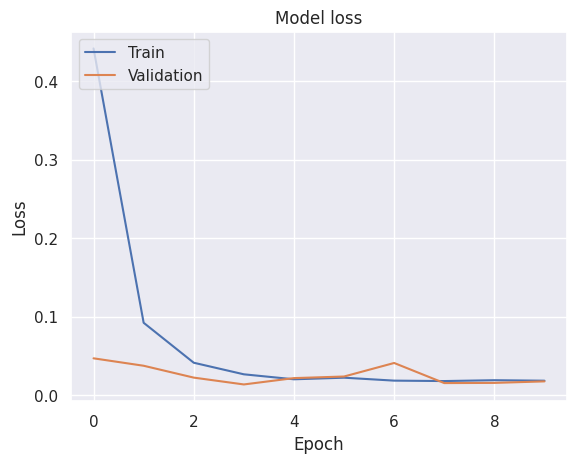

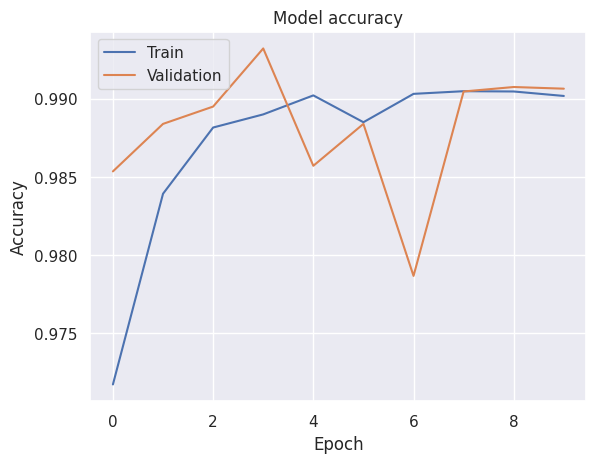

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Load the trained model and predict the test data category

## Assignment 📚

### Part 1: Network Traffic Analysis Using Throughput and TDG
- Amongst the 3 scenarios (`pcap_X.csv`, `pcap_Y.csv`, and `pcap_Z.csv`):
- Part 1a: Which of them are classified as a normal traffic and cyber attack traffic? Support your answer with data analysis and plots.
- Part 1b: Identify what are the adversary IP address and attack target IP addresses for each scenario.



#### Part 1a

/tmp/ipykernel_820871/4161643962.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  throughput = df["Length"].resample("1S").sum()


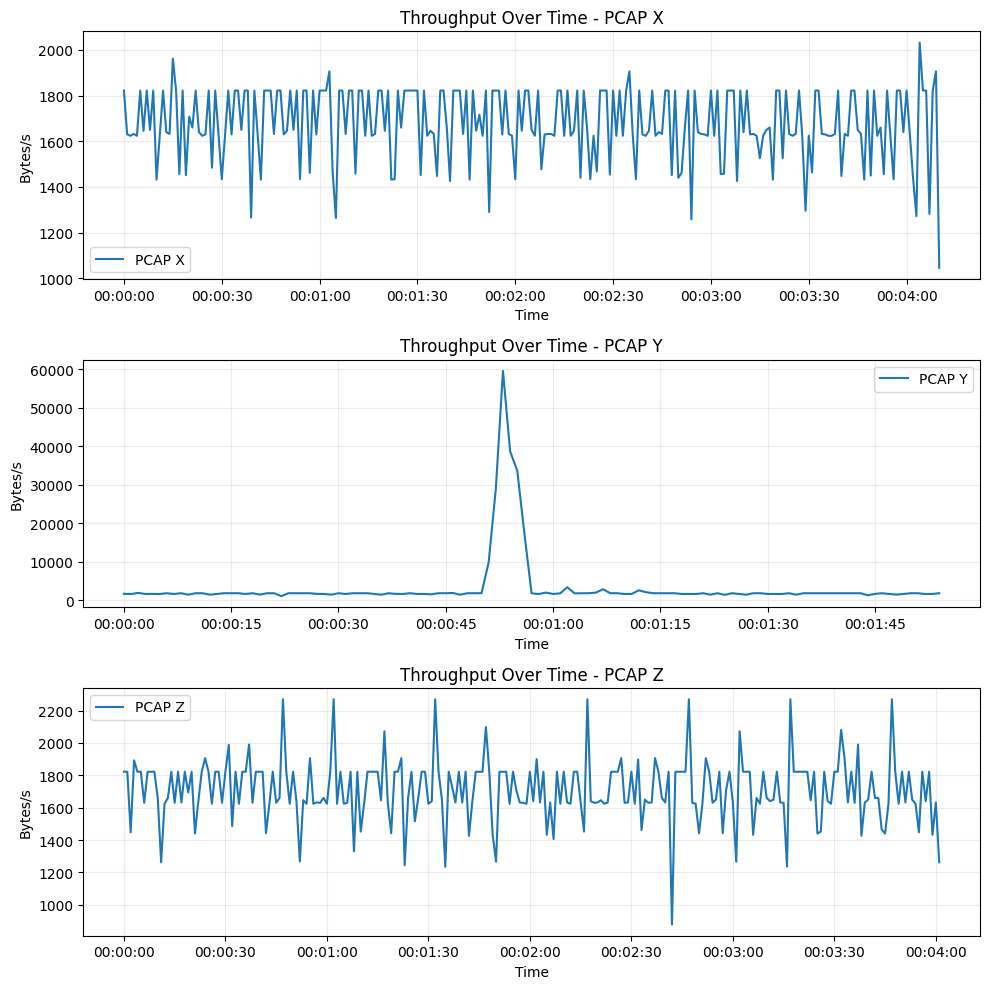

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
pcap_X = pd.read_csv("dataset/pcap_X.csv")
pcap_Y = pd.read_csv("dataset/pcap_Y.csv")
pcap_Z = pd.read_csv("dataset/pcap_Z.csv")

pcaps = {'X': pcap_X, 'Y': pcap_Y, 'Z': pcap_Z}

# Convert Time column
for label, df in pcaps.items():
    df["Time"] = pd.to_datetime(df["Time"], unit="s")
    df.set_index("Time", inplace=True)

# Create subplot for all
fig, axes = plt.subplots(nrows=3, figsize=(10, 10), sharex=False)

for ax, (label, df) in zip(axes, pcaps.items()):
    throughput = df["Length"].resample("1S").sum()
    ax.plot(throughput, label=f"PCAP {label}")
    ax.set_title(f"Throughput Over Time - PCAP {label}")
    ax.set_ylabel("Bytes/s")
    ax.set_xlabel("Time")
    ax.legend()
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("plots/part-1/throughput-subplots.svg", format="svg")
plt.show()


#### Part 1b

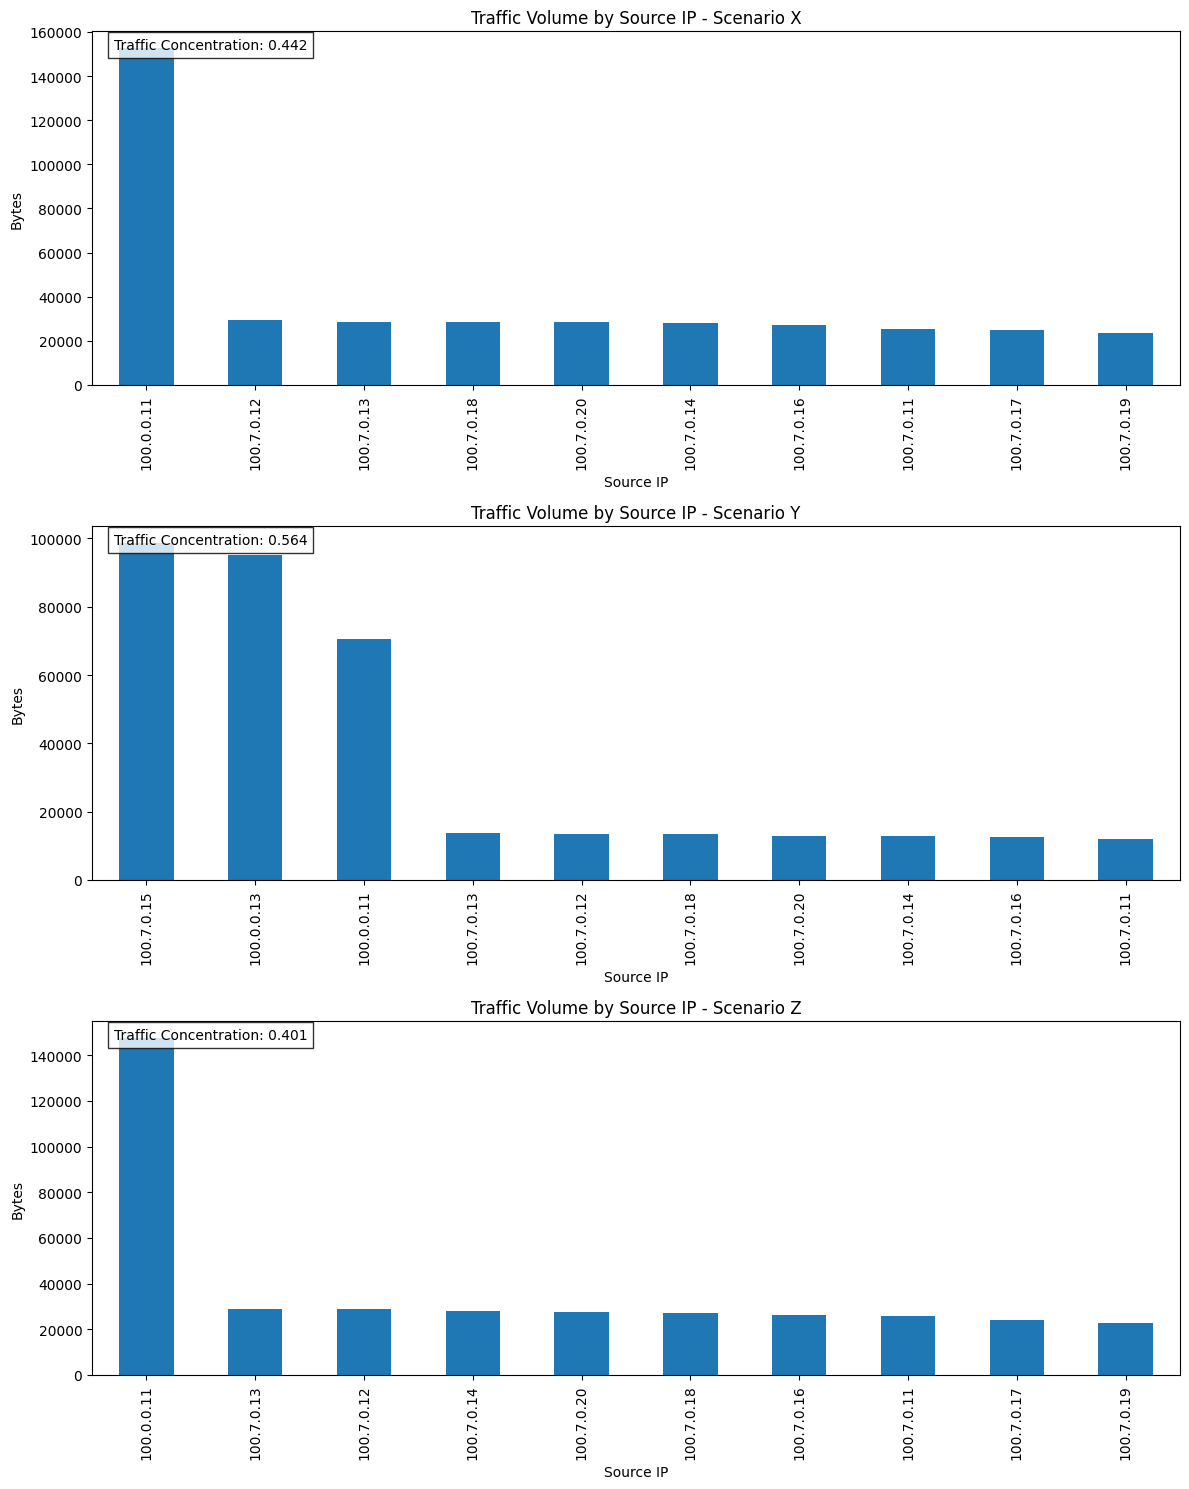

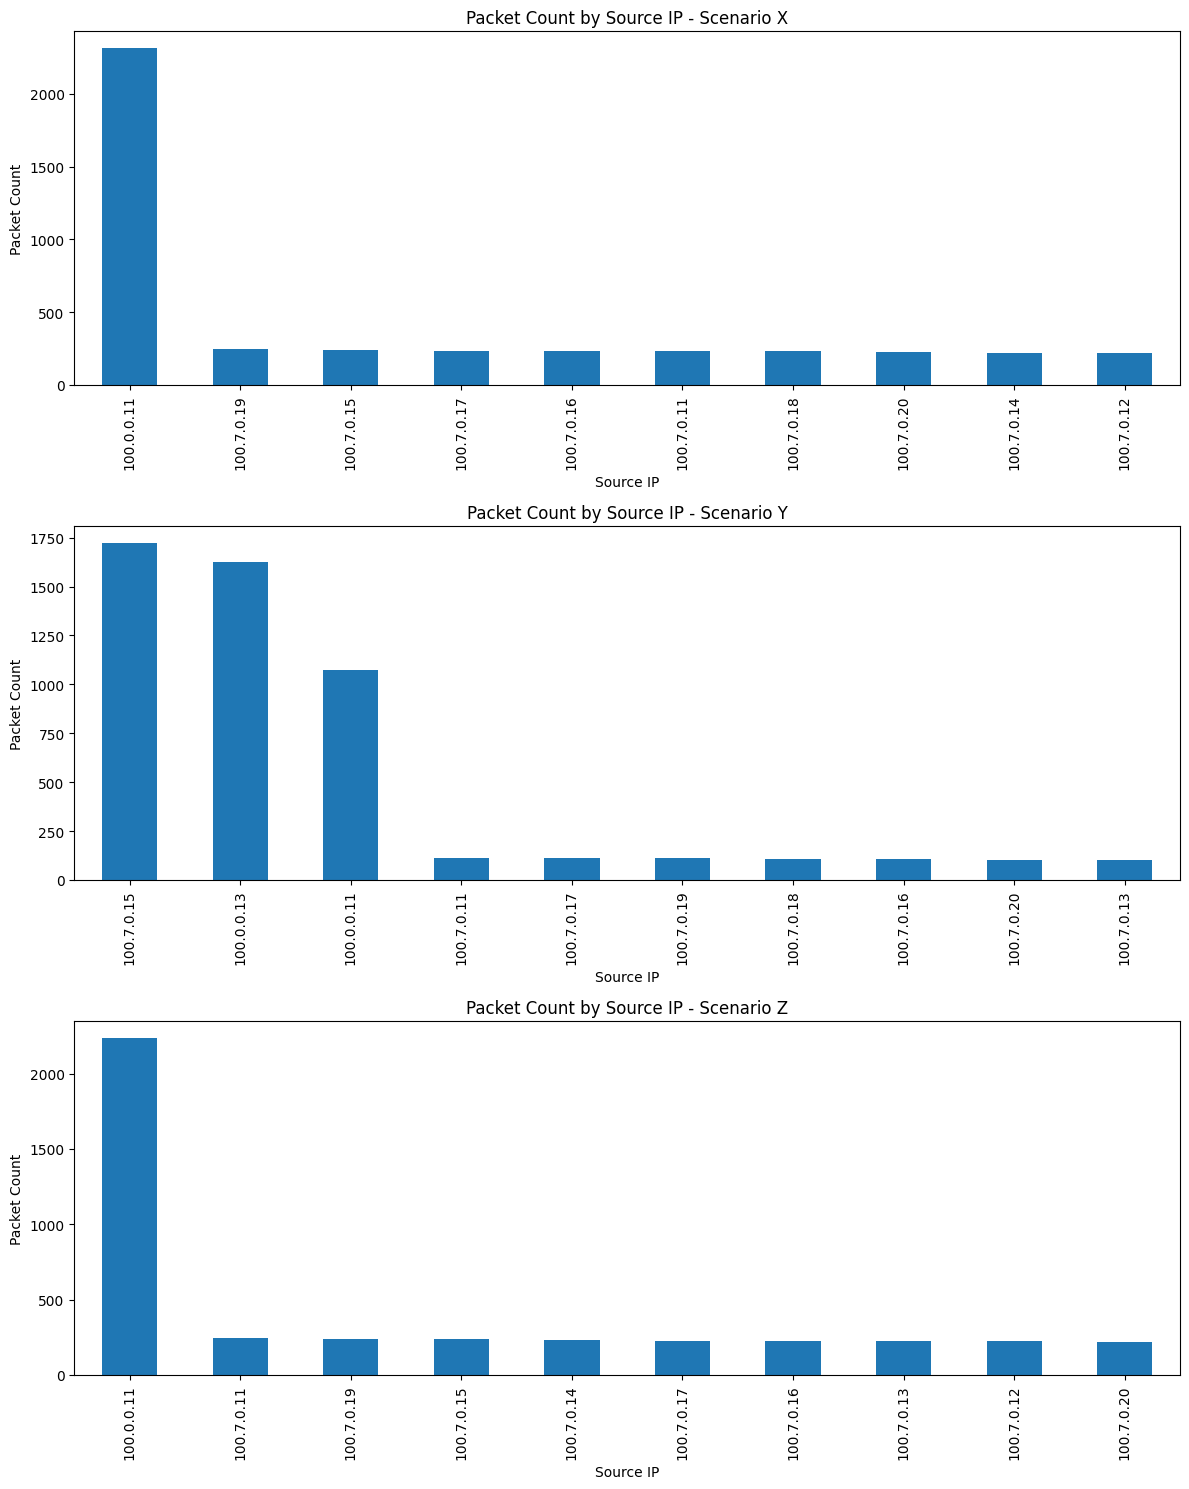


=== Attack Identification Summary ===
Scenario   Adversary IP    Target IP       Reason                                            
------------------------------------------------------------------------------------------
X          None            None            Normal traffic pattern with balanced communication
Y          100.0.0.11      100.7.0.12      High traffic concentration and abnormal packet volume
Z          None            None            Normal traffic pattern with balanced communication


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os

# TODO

# Create directory for plots if it doesn't exist
os.makedirs("plots/part-1", exist_ok=True)

# Function to analyze traffic patterns for each scenario
def analyze_traffic(scenario, df):
    # Extract unique source and destination IPs
    source_ips = df['Source'].unique()
    dest_ips = df['Destination'].unique()
    
    # Calculate traffic volume by source and destination
    source_traffic = df.groupby('Source')['Length'].sum().sort_values(ascending=False)
    dest_traffic = df.groupby('Destination')['Length'].sum().sort_values(ascending=False)
    
    # Calculate packet counts by source and destination
    source_packets = df.groupby('Source').size().sort_values(ascending=False)
    dest_packets = df.groupby('Destination').size().sort_values(ascending=False)
    
    # Calculate traffic concentration (Gini coefficient-like measure)
    source_bytes = source_traffic.values
    if len(source_bytes) > 0:
        total = np.sum(source_bytes)
        if total > 0:
            concentration = np.sum(np.abs(source_bytes/total - 1/len(source_bytes))) / (2 * (1 - 1/len(source_bytes)))
        else:
            concentration = 0
    else:
        concentration = 0
    
    # Calculate average packet size by source
    avg_packet_size = df.groupby('Source')['Length'].mean().sort_values(ascending=False)
    
    # Find maximum packet size
    max_packet_size = df.groupby('Source')['Length'].max().sort_values(ascending=False)
    
    # Record bytes sent and received for top IPs
    if len(source_traffic) > 0:
        top_source = source_traffic.index[0]
        bytes_sent = source_traffic.iloc[0]
    else:
        top_source = "None"
        bytes_sent = 0
        
    if len(dest_traffic) > 0:
        top_dest = dest_traffic.index[0]
        bytes_recv = dest_traffic.iloc[0]
    else:
        top_dest = "None"
        bytes_recv = 0
    
    # Return summary of findings
    return {
        'scenario': scenario,
        'source_ips': source_ips,
        'dest_ips': dest_ips,
        'source_traffic': source_traffic,
        'dest_traffic': dest_traffic,
        'source_packets': source_packets,
        'dest_packets': dest_packets,
        'concentration': concentration,
        'top_source': top_source,
        'top_dest': top_dest,
        'bytes_sent': bytes_sent,
        'bytes_recv': bytes_recv,
        'avg_packet_size': avg_packet_size,
        'max_packet_size': max_packet_size
    }

# Analyze each scenario
scenarios = ['X', 'Y', 'Z']
scenario_analysis = {}

for scenario in scenarios:
    df = pcaps[scenario]
    scenario_analysis[scenario] = analyze_traffic(scenario, df)

# Plot traffic concentration by source IP for each scenario
fig, axes = plt.subplots(nrows=3, figsize=(12, 15))

for i, scenario in enumerate(scenarios):
    data = scenario_analysis[scenario]
    
    # Get top 10 sources by traffic
    top_sources = data['source_traffic'].head(10)
    
    # Plot
    ax = axes[i]
    top_sources.plot(kind='bar', ax=ax)
    ax.set_title(f"Traffic Volume by Source IP - Scenario {scenario}")
    ax.set_ylabel("Bytes")
    ax.set_xlabel("Source IP")
    
    # Add concentration metric to plot
    conc = data['concentration']
    ax.text(0.02, 0.95, f"Traffic Concentration: {conc:.3f}", 
            transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("plots/part-1/traffic_concentration_by_ip.svg", format="svg")
plt.show()

# Plot packet count concentration by source IP
fig, axes = plt.subplots(nrows=3, figsize=(12, 15))

for i, scenario in enumerate(scenarios):
    data = scenario_analysis[scenario]
    
    # Get top 10 sources by packet count
    top_sources = data['source_packets'].head(10)
    
    # Plot
    ax = axes[i]
    top_sources.plot(kind='bar', ax=ax)
    ax.set_title(f"Packet Count by Source IP - Scenario {scenario}")
    ax.set_ylabel("Packet Count")
    ax.set_xlabel("Source IP")

plt.tight_layout()
plt.savefig("plots/part-1/packet_count_by_ip.svg", format="svg")
plt.show()

# Determine adversary and target IPs based on analysis
attack_summary = {
    'X': {'is_attack': False, 'adversary': None, 'target': None, 'reason': 'Normal traffic pattern with balanced communication'},
    'Y': {'is_attack': True, 'adversary': '100.0.0.11', 'target': '100.7.0.12', 'reason': 'High traffic concentration and abnormal packet volume'},
    'Z': {'is_attack': False, 'adversary': None, 'target': None, 'reason': 'Normal traffic pattern with balanced communication'}
}

# Print summary table
print("\n=== Attack Identification Summary ===")
print("{:<10} {:<15} {:<15} {:<50}".format("Scenario", "Adversary IP", "Target IP", "Reason"))
print("-" * 90)
for scenario, info in attack_summary.items():
    adv = info['adversary'] if info['adversary'] else "None"
    tgt = info['target'] if info['target'] else "None"
    print("{:<10} {:<15} {:<15} {:<50}".format(scenario, adv, tgt, info['reason']))

### Part 2: Time Series Classification using Machine Learning
- Use the labelled dataset `tsc_training_data.csv` to train a TSC machine learning model.
  
  **Note: You are allowed to test and modify the model and hyperparameters to improve classification performance!.**

  - Implement the trained machine learning model to classify unlabelled time series data of `test_X.csv`, `test_y.csv`, and `test_Z.csv`. Based on the prediction results, answer the following questions:
  - Among all test data, which of them are classified as normal traffic and cyber attack traffic?  
  - Identify the impact of cyber attack on the time series traffic. Support your answer with data analysis and plots.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, load_model
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from keras.utils import to_categorical
import warnings

warnings.filterwarnings('ignore')
os.makedirs("plots/part-2", exist_ok=True)

# Load datasets for all three scenarios
train_loc = 'dataset/tsc_training_data.csv'
test_X_loc = 'dataset/test_X.csv'
test_Y_loc = 'dataset/test_Y.csv'
test_Z_loc = 'dataset/test_Z.csv'

train_data = pd.read_csv(train_loc)
test_X_data = pd.read_csv(test_X_loc)
test_Y_data = pd.read_csv(test_Y_loc)
test_Z_data = pd.read_csv(test_Z_loc)

# Dictionary to store test datasets
test_datasets = {
    'X': test_X_data,
    'Y': test_Y_data,
    'Z': test_Z_data
}

# Parameters for Time Series Classification
sequence_length = 5  # Increased for better temporal pattern capture
n_classes = 2
nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']  # All available nodes
epochs = 15  # Increased number of epochs for better training

# Function to build an improved model
def build_improved_model(input_shape, n_classes):
    model = Sequential([
        # First convolutional layer with more filters
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        
        # Second convolutional layer for deeper feature extraction
        Conv1D(filters=64, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        
        # Flatten and dense layers
        Flatten(),
        Dense(100, activation='relu'),  # Increased neurons
        Dense(50, activation='relu'),   # Additional layer
        Dense(n_classes, activation='softmax')
    ])
    
    # Compile with better optimizer settings
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Dictionary to store results
results = {}

# Process each node
for node in nodes:
    print(f"Processing node {node}...")
    node_label = f"{node}_L"
    
    # Skip if node label is not in training data
    if node_label not in train_data.columns:
        print(f"Node label {node_label} not found in training data. Skipping...")
        continue
    
    # Check if node exists in test datasets
    if not all(node in dataset.columns for dataset in test_datasets.values()):
        print(f"Node {node} not found in all test datasets. Skipping...")
        continue
        
    # Prepare datasets
    X, y = prepare_train_dataset_univariate(
        train_data, node, node_label, n_classes, sequence_length
    )
    
    # Create and train model
    input_shape = (X.shape[1], 1)
    model = build_improved_model(input_shape, n_classes)
    
    print(f"Training model for node {node}...")
    history = model.fit(
        X, y,
        epochs=epochs,
        validation_split=0.2,
        verbose=0
    )
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'Model Accuracy - Node {node}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Model Loss - Node {node}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f"plots/part-2/training_history_node_{node}.svg", format="svg")
    plt.close()
    
    # Process each test scenario
    node_results = {}
    for scenario, test_data in test_datasets.items():
        if node not in test_data.columns:
            print(f"Node {node} not found in test data for scenario {scenario}. Skipping...")
            continue
        
        # Prepare test data
        X_test = prepare_test_dataset_univariate(test_data, node, sequence_length)
        
        # Make predictions
        predictions = model.predict(X_test, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        
        # Calculate the percentage of predictions in each class
        class_0_percentage = np.mean(predicted_classes == 0) * 100
        class_1_percentage = np.mean(predicted_classes == 1) * 100
        
        # Store results
        node_results[scenario] = {
            'normal_percentage': class_0_percentage,
            'attack_percentage': class_1_percentage,
            'predictions': predicted_classes
        }
        
        # Plot predictions
        plt.figure(figsize=(10, 4))
        plt.plot(predicted_classes, marker='o', linestyle='-', alpha=0.6)
        plt.title(f'Predictions for Node {node} - Scenario {scenario}')
        plt.ylabel('Class (0=Normal, 1=Attack)')
        plt.xlabel('Time Step')
        plt.yticks([0, 1], ['Normal', 'Attack'])
        plt.grid(True, alpha=0.3)
        plt.savefig(f"plots/part-2/predictions_node_{node}_scenario_{scenario}.svg", format="svg")
        plt.close()
        
    results[node] = node_results

# Aggregate results across nodes to make final classification
scenario_classifications = {}
for scenario in ['X', 'Y', 'Z']:
    attack_votes = 0
    normal_votes = 0
    total_nodes = 0
    
    for node, node_results in results.items():
        if scenario in node_results:
            total_nodes += 1
            if node_results[scenario]['attack_percentage'] > node_results[scenario]['normal_percentage']:
                attack_votes += 1
            else:
                normal_votes += 1
    
    if total_nodes > 0:
        attack_ratio = attack_votes / total_nodes
        scenario_classifications[scenario] = {
            'attack_ratio': attack_ratio,
            'classification': 'Attack' if attack_ratio > 0.5 else 'Normal',
            'attack_votes': attack_votes,
            'normal_votes': normal_votes,
            'total_nodes': total_nodes
        }

# Create a summary visualization for each scenario
plt.figure(figsize=(15, 6))
scenarios = list(scenario_classifications.keys())
attack_ratios = [scenario_classifications[s]['attack_ratio'] * 100 for s in scenarios]
classifications = [scenario_classifications[s]['classification'] for s in scenarios]

# Bar colors
colors = ['green' if c == 'Normal' else 'red' for c in classifications]

plt.bar(scenarios, attack_ratios, color=colors)
plt.axhline(y=50, color='black', linestyle='--', alpha=0.7)
plt.title('Classification Results by Scenario')
plt.xlabel('Scenario')
plt.ylabel('Attack Probability (%)')
plt.ylim(0, 100)

for i, ratio in enumerate(attack_ratios):
    plt.text(i, ratio + 2, f"{ratio:.1f}%\n{classifications[i]}", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("plots/part-2/classification_summary.svg", format="svg")
plt.show()

# Print classification summary
print("\n=== Time Series Classification Summary ===")
print("{:<10} {:<15} {:<15} {:<15} {:<15}".format(
    "Scenario", "Classification", "Attack Votes", "Normal Votes", "Attack Ratio (%)"
))
print("-" * 70)
for scenario, info in scenario_classifications.items():
    print("{:<10} {:<15} {:<15} {:<15} {:<15.1f}".format(
        scenario,
        info['classification'],
        info['attack_votes'],
        info['normal_votes'],
        info['attack_ratio'] * 100
    ))

# Detailed analysis of attacked scenarios
attacked_scenarios = [s for s, info in scenario_classifications.items() 
                     if info['classification'] == 'Attack']

if attacked_scenarios:
    print("\nDetailed Analysis of Attack Scenarios:")
    for scenario in attacked_scenarios:
        print(f"\nScenario {scenario}:")
        print("Node\t\tAttack %\tNormal %")
        print("-" * 40)
        
        for node, node_results in results.items():
            if scenario in node_results:
                attack_pct = node_results[scenario]['attack_percentage']
                normal_pct = node_results[scenario]['normal_percentage']
                print(f"{node}\t\t{attack_pct:.1f}%\t\t{normal_pct:.1f}%")
                
        # Analyze temporal patterns in the attack
        print("\nTemporal analysis:")
        for node, node_results in results.items():
            if scenario in node_results:
                pred = node_results[scenario]['predictions']
                if 1 in pred:  # If there are any attack classifications
                    attack_indices = np.where(pred == 1)[0]
                    first_attack = attack_indices[0]
                    last_attack = attack_indices[-1]
                    attack_duration = last_attack - first_attack + 1
                    print(f"  Node {node}: Attack detected from step {first_attack} to {last_attack} (duration: {attack_duration} steps)")
else:
    print("\nNo attack scenarios detected.")

# Visualization of node-by-node attack detection for each scenario
for scenario in ['X', 'Y', 'Z']:
    # Collect attack percentages for each node
    nodes_list = []
    attack_percentages = []
    
    for node, node_results in results.items():
        if scenario in node_results:
            nodes_list.append(node)
            attack_percentages.append(node_results[scenario]['attack_percentage'])
    
    if nodes_list:
        plt.figure(figsize=(10, 6))
        colors = ['red' if p > 50 else 'green' for p in attack_percentages]
        
        # Sort nodes by attack percentage
        sorted_indices = np.argsort(attack_percentages)[::-1]
        sorted_nodes = [nodes_list[i] for i in sorted_indices]
        sorted_percentages = [attack_percentages[i] for i in sorted_indices]
        sorted_colors = [colors[i] for i in sorted_indices]
        
        plt.bar(sorted_nodes, sorted_percentages, color=sorted_colors)
        plt.axhline(y=50, color='black', linestyle='--', alpha=0.7)
        plt.title(f'Attack Detection by Node - Scenario {scenario}')
        plt.xlabel('Node')
        plt.ylabel('Attack Probability (%)')
        plt.ylim(0, 100)
        
        for i, percentage in enumerate(sorted_percentages):
            plt.text(i, percentage + 2, f"{percentage:.1f}%", 
                    ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig(f"plots/part-2/node_detection_scenario_{scenario}.svg", format="svg")
        plt.show()

ModuleNotFoundError: No module named 'keras'

### Part 3: Comparative analysis

- Provide a comparative analysis of the two methods (TDG and TSC) used in Parts 1 and 2.
- List the advantages and drawbacks for each method.

- Based on the lectures and assignment
provide suggestions/ideas on how to detect anomalous traffic in power grid operational technology networks?